# Linear Regression and Gradient Descent
## Theory, Mathematics, and Implementation — Diabetes Disease Progression Prediction

This notebook builds linear regression **from first principles**, derives gradient descent
by hand, implements it in NumPy, visualizes convergence on an animated 3D cost surface,
and compares the result against scikit-learn's closed-form and SGD solvers on the
**diabetes dataset** (442 patients, predicting quantitative disease progression one year after baseline).

**Contents**
1. Setup and data exploration
2. Linear regression: the model and the cost function
3. The normal equation (closed-form solution)
4. Gradient descent: derivation from calculus
5. Implementing batch gradient descent in NumPy
6. Visualizing the cost surface and gradient descent path (2D projection + animated 3D surface)
7. Applying gradient descent to the diabetes dataset (single feature, then full feature set)
8. Comparing gradient descent vs. the normal equation vs. scikit-learn
9. Effect of learning rate, feature scaling, and diagnostics
10. Conclusion


## 1. Setup and Data Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from IPython.display import HTML

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries loaded.")


Libraries loaded.


In [2]:
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame.copy()
df.rename(columns={'target': 'disease_progression'}, inplace=True)

print("Dataset shape:", df.shape)
print("\nFeature descriptions:")
print(diabetes.DESCR.split('Attribute Information:')[1].split('Note:')[0])

df.head()


Dataset shape: (442, 11)

Feature descriptions:

    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level




,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
# Standardize every feature to mean 0, standard deviation 1 (see note below).
feature_cols = [c for c in df.columns if c != 'disease_progression']
scaler_all = StandardScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler_all.fit_transform(df[feature_cols])

print("Standard deviation before standardizing:")
print(df[feature_cols].std().round(4).to_dict())
print("\nStandard deviation after standardizing:")
print(df_scaled[feature_cols].std().round(4).to_dict())


Standard deviation before standardizing:
{'age': 0.0476, 'sex': 0.0476, 'bmi': 0.0476, 'bp': 0.0476, 's1': 0.0476, 's2': 0.0476, 's3': 0.0476, 's4': 0.0476, 's5': 0.0476, 's6': 0.0476}

Standard deviation after standardizing:
{'age': 1.0011, 'sex': 1.0011, 'bmi': 1.0011, 'bp': 1.0011, 's1': 1.0011, 's2': 1.0011, 's3': 1.0011, 's4': 1.0011, 's5': 1.0011, 's6': 1.0011}


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.268604e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


**Note on scaling:** scikit-learn's `load_diabetes` ships the 10 features
mean-centered, but each column is scaled so that its *sum of squares* (not its
variance) equals 1 — so individual columns can still have very different standard
deviations (e.g., `bmi` has a standard deviation around 0.048, not 1). For gradient
descent to behave predictably at a single learning rate, we additionally standardize
each feature to zero mean and **unit variance** below with `StandardScaler`. This is
standard practice and is exactly what makes the cost surface close to circular
(isotropic) — we'll see why that matters in Section 6.

The **target**, `disease_progression`, is a *continuous* quantitative score, so this is a
genuine regression problem, not classification.

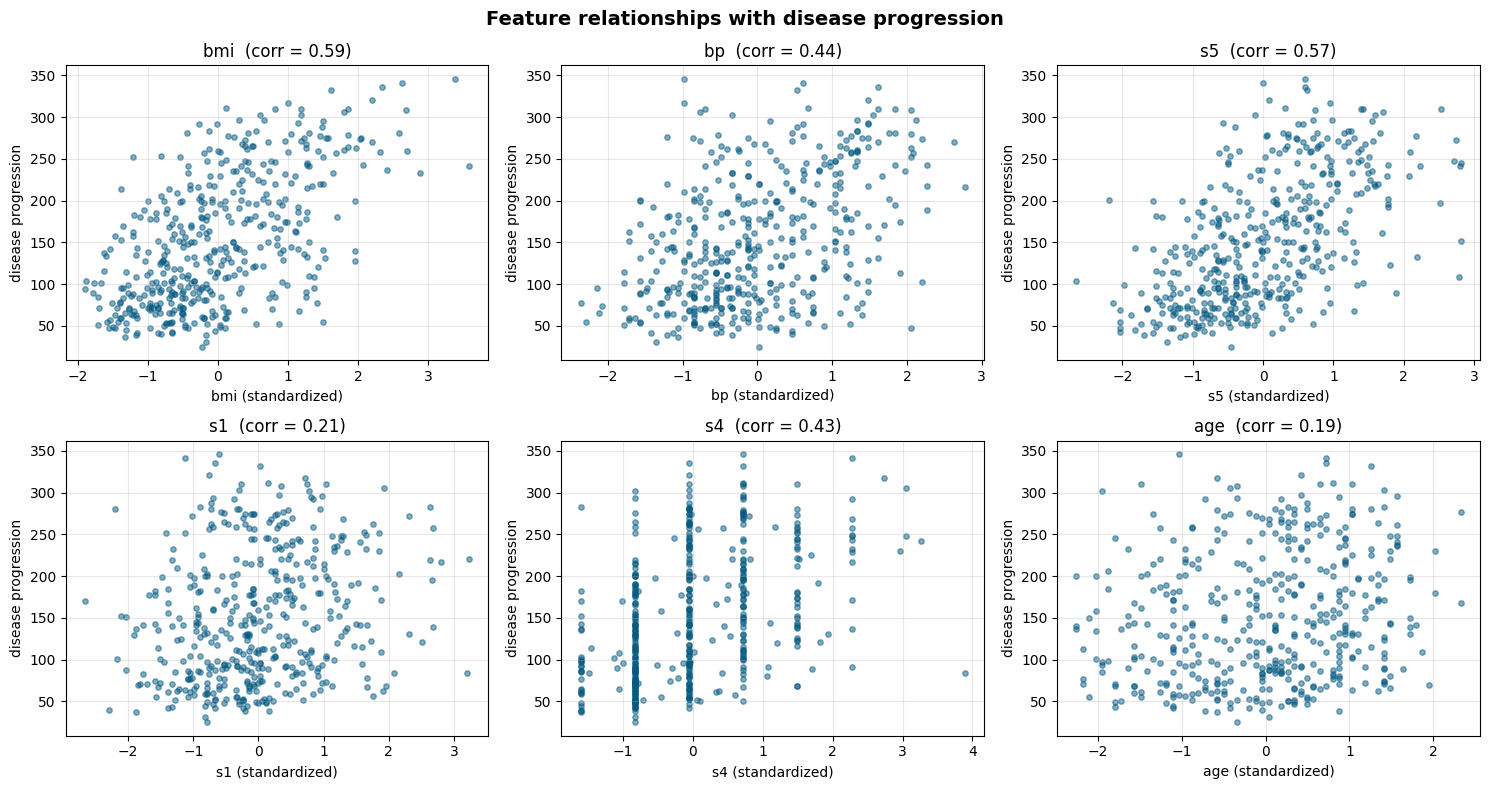

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
key_features = ['bmi', 'bp', 's5', 's1', 's4', 'age']
for ax, feat in zip(axes.ravel(), key_features):
    ax.scatter(df_scaled[feat], df_scaled['disease_progression'], alpha=0.5, s=15, color='#065A82')
    ax.set_xlabel(feat + ' (standardized)')
    ax.set_ylabel('disease progression')
    corr = df_scaled[feat].corr(df_scaled['disease_progression'])
    ax.set_title(f"{feat}  (corr = {corr:.2f})")
plt.suptitle("Feature relationships with disease progression", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feature_scatter.png', dpi=140, bbox_inches='tight')
plt.show()


`bmi` and `s5` (log serum triglycerides) show the strongest linear relationship with
the target, so we'll use **bmi** as our single-feature running example before extending
to the full 10-feature model.

## 2. Linear Regression: The Model and the Cost Function

### 2.1 The model

For a single feature (simple linear regression), we hypothesize a linear relationship
between the input $x$ (e.g., BMI) and the target $y$ (disease progression):

$$\hat{y} = h_\theta(x) = \theta_0 + \theta_1 x$$

For $n$ features (multiple linear regression), with weight vector $\theta = [\theta_0, \theta_1, \dots, \theta_n]^T$
and input vector $x = [1, x_1, \dots, x_n]^T$ (the leading 1 absorbs the intercept $\theta_0$):

$$\hat{y} = h_\theta(x) = \theta^T x = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n$$

In matrix form, for $m$ training examples stacked into design matrix $X \in \mathbb{R}^{m \times (n+1)}$:

$$\hat{y} = X\theta$$

### 2.2 The cost function

We need a way to measure how wrong our predictions are. The standard choice for linear
regression is **Mean Squared Error (MSE)**, expressed here as the conventional
**half-MSE cost function** $J(\theta)$ (the $\frac{1}{2}$ is a convenience that cancels
neatly during differentiation):

$$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)}) - y^{(i)}\right)^2 = \frac{1}{2m}\sum_{i=1}^{m}\left(\theta^T x^{(i)} - y^{(i)}\right)^2$$

or in vectorized form:

$$J(\theta) = \frac{1}{2m}(X\theta - y)^T(X\theta - y)$$

**Why squared error?** Squaring penalizes larger errors disproportionately, keeps the
cost differentiable everywhere, and — critically for this notebook — makes $J(\theta)$ a
**convex paraboloid** in $\theta$-space. Convexity guarantees gradient descent converges
to the *global* minimum, not just a local one. This convex bowl shape is exactly what
we'll visualize as a 3D surface in Section 6.

**Goal:** find $\theta^* = \arg\min_\theta J(\theta)$.

There are two ways to find $\theta^*$: solve for it directly (the normal equation) or
search for it iteratively (gradient descent). We derive both below.

## 3. The Normal Equation (Closed-Form Solution)

Because $J(\theta)$ is convex and differentiable, we can find its minimum analytically by
setting the gradient to zero: $\nabla_\theta J(\theta) = 0$.

Expanding $J(\theta) = \frac{1}{2m}(X\theta - y)^T(X\theta - y)$ and differentiating with
respect to $\theta$:

$$\nabla_\theta J(\theta) = \frac{1}{m}X^T(X\theta - y) = 0$$

$$X^TX\theta = X^Ty$$

$$\boxed{\theta = (X^TX)^{-1}X^Ty}$$

This is the **normal equation**. It gives the exact optimum in one step — no iteration,
no learning rate. So why do we need gradient descent at all?

- $(X^TX)^{-1}$ costs $O(n^3)$ to compute. With thousands of features (e.g., text,
  genomic, or image data), this becomes computationally prohibitive.
- $X^TX$ can be singular or ill-conditioned (features that are collinear or when
  $m < n$), making inversion unstable.
- Many models beyond plain linear regression (logistic regression, neural networks,
  regularized/robust variants) have **no closed-form solution at all** — gradient
  descent (or a variant of it) is the *only* practical option.

We'll compute the normal-equation solution here as our ground truth, then show gradient
descent converging to the same point.

In [6]:
def normal_equation(X, y):
    """Closed-form OLS solution: theta = (X^T X)^-1 X^T y"""
    return np.linalg.inv(X.T @ X) @ X.T @ y

# Single-feature example: standardized bmi -> disease progression
x_bmi = df_scaled['bmi'].values
y = df_scaled['disease_progression'].values
m = len(y)

X_simple = np.column_stack([np.ones(m), x_bmi])   # design matrix [1, x]
theta_normal_eq = normal_equation(X_simple, y)

print(f"Normal equation solution:  theta_0 (intercept) = {theta_normal_eq[0]:.3f}")
print(f"                           theta_1 (slope)     = {theta_normal_eq[1]:.3f}")

J_normal_eq = np.mean((X_simple @ theta_normal_eq - y) ** 2) / 2
print(f"\nCost J(theta) at this optimum: {J_normal_eq:.3f}")


Normal equation solution:  theta_0 (intercept) = 152.133
                           theta_1 (slope)     = 45.160

Cost J(theta) at this optimum: 1945.228


## 4. Gradient Descent: Derivation from Calculus

Gradient descent finds the minimum of $J(\theta)$ **iteratively**, by repeatedly stepping
in the direction that decreases the cost fastest — the direction *opposite* the gradient
(since the gradient points toward steepest *ascent*).

### 4.1 The update rule

$$\theta := \theta - \alpha \nabla_\theta J(\theta)$$

where $\alpha$ is the **learning rate**, controlling step size.

### 4.2 Deriving the gradient for linear regression

For a single training example, the squared error is $\frac{1}{2}(h_\theta(x) - y)^2$.
Taking the partial derivative with respect to a single parameter $\theta_j$, using the
chain rule:

$$\frac{\partial}{\partial \theta_j}\frac{1}{2}(h_\theta(x)-y)^2 = (h_\theta(x)-y)\cdot\frac{\partial}{\partial \theta_j}(h_\theta(x)-y) = (h_\theta(x)-y)\cdot x_j$$

since $\frac{\partial}{\partial \theta_j}h_\theta(x) = \frac{\partial}{\partial \theta_j}\sum_k \theta_k x_k = x_j$.

Summing over all $m$ examples (this is **batch** gradient descent — every example
contributes to each update):

$$\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)}) - y^{(i)}\right)x_j^{(i)}$$

In vectorized matrix form, for the full parameter vector:

$$\nabla_\theta J(\theta) = \frac{1}{m}X^T(X\theta - y)$$

So the full **batch gradient descent update rule** is:

$$\boxed{\theta := \theta - \frac{\alpha}{m}X^T(X\theta - y)}$$

repeated until $J(\theta)$ converges (stops decreasing meaningfully) or a fixed number
of iterations is reached.

### 4.3 Why this works: intuition

- If a prediction is too high ($h_\theta(x) > y$), the error term is positive, so we
  *decrease* $\theta_j$ (when $x_j > 0$) — pulling the prediction down.
- If too low, we increase $\theta_j$.
- The step size scales with both $\alpha$ and the magnitude of the error — larger
  mistakes produce larger corrective steps.
- Because $J(\theta)$ is a convex paraboloid, following the negative gradient always
  moves toward the single global minimum — there are no local minima to get trapped in.

### 4.4 Variants

| Variant | Examples per update | Behavior |
|---|---|---|
| **Batch GD** | All $m$ examples | Smooth, deterministic convergence; expensive per step for large $m$ |
| **Stochastic GD (SGD)** | 1 example | Noisy path, fast updates, can escape shallow local minima (irrelevant here since convex) |
| **Mini-batch GD** | A small batch (e.g., 32) | The practical default — balances stability and speed |

We implement batch gradient descent by hand below, since it visualizes most cleanly, and
compare against scikit-learn's `SGDRegressor` afterward.

In [7]:
def compute_cost(X, y, theta):
    """Half-MSE cost J(theta) = (1/2m) * sum((X @ theta - y)^2)"""
    m = len(y)
    errors = X @ theta - y
    return (1 / (2 * m)) * np.sum(errors ** 2)

def gradient_descent(X, y, theta_init, alpha, n_iterations):
    """
    Batch gradient descent for linear regression.
    Returns the final theta, and the full history of theta and cost for visualization.
    """
    m = len(y)
    theta = theta_init.copy()
    theta_history = [theta.copy()]
    cost_history = [compute_cost(X, y, theta)]

    for _ in range(n_iterations):
        gradient = (1 / m) * X.T @ (X @ theta - y)
        theta = theta - alpha * gradient
        theta_history.append(theta.copy())
        cost_history.append(compute_cost(X, y, theta))

    return theta, np.array(theta_history), np.array(cost_history)

print("compute_cost and gradient_descent implemented.")


compute_cost and gradient_descent implemented.


## 5. Running Gradient Descent on the Diabetes Data (Single Feature)

We run our hand-written batch gradient descent on `bmi -> disease_progression` and
confirm it converges to the same $\theta$ as the normal equation.

Because `bmi` is already standardized (mean $\approx 0$, unit variance-ish) in this
dataset, gradient descent behaves well even at a healthy learning rate. We'll deliberately
explore what happens *without* this nice scaling later in Section 9.

In [8]:
theta_init = np.zeros(2)
alpha = 0.5
n_iter = 100

theta_gd, theta_hist, cost_hist = gradient_descent(X_simple, y, theta_init, alpha, n_iter)

print(f"Gradient descent result  (alpha={alpha}, {n_iter} iterations):")
print(f"  theta_0 = {theta_gd[0]:.3f}   theta_1 = {theta_gd[1]:.3f}")
print(f"\nNormal equation result (ground truth):")
print(f"  theta_0 = {theta_normal_eq[0]:.3f}   theta_1 = {theta_normal_eq[1]:.3f}")
print(f"\nFinal cost J(theta):        {cost_hist[-1]:.4f}")
print(f"Normal-equation optimal cost: {J_normal_eq:.4f}")
print(f"\nDifference in theta: {np.linalg.norm(theta_gd - theta_normal_eq):.6f}  (should be ~0)")


Gradient descent result  (alpha=0.5, 100 iterations):
  theta_0 = 152.133   theta_1 = 45.160

Normal equation result (ground truth):
  theta_0 = 152.133   theta_1 = 45.160

Final cost J(theta):        1945.2283
Normal-equation optimal cost: 1945.2283

Difference in theta: 0.000000  (should be ~0)


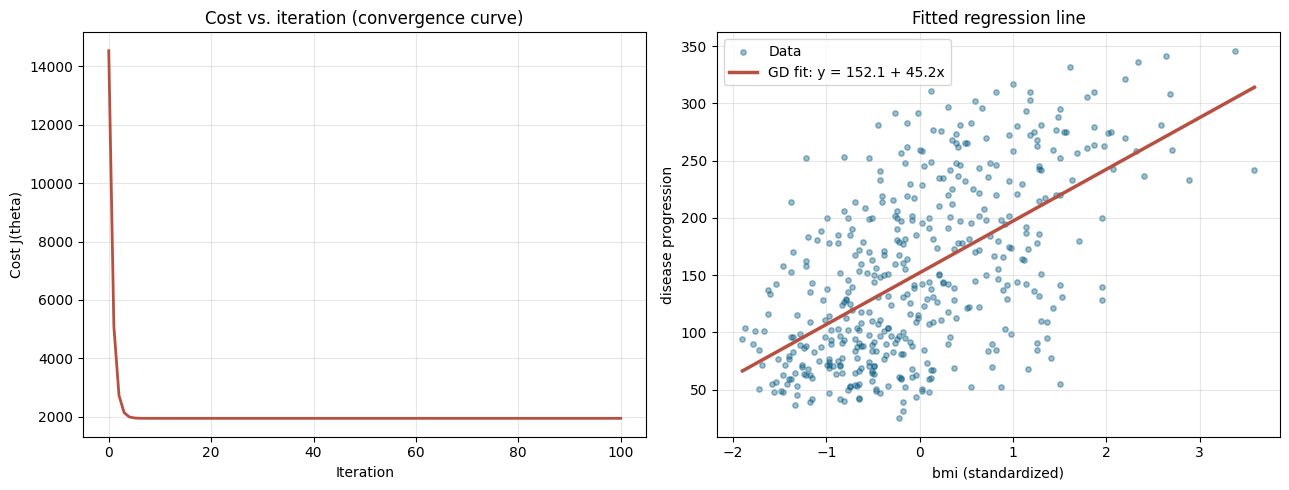

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(cost_hist, color='#B85042', linewidth=2)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Cost J(theta)')
ax1.set_title('Cost vs. iteration (convergence curve)')

ax2.scatter(x_bmi, y, alpha=0.4, s=15, color='#065A82', label='Data')
x_line = np.linspace(x_bmi.min(), x_bmi.max(), 100)
ax2.plot(x_line, theta_gd[0] + theta_gd[1] * x_line, color='#B85042', linewidth=2.5,
         label=f'GD fit: y = {theta_gd[0]:.1f} + {theta_gd[1]:.1f}x')
ax2.set_xlabel('bmi (standardized)')
ax2.set_ylabel('disease progression')
ax2.set_title('Fitted regression line')
ax2.legend()

plt.tight_layout()
plt.savefig('fig_convergence_and_fit.png', dpi=140, bbox_inches='tight')
plt.show()


Gradient descent converges to (essentially) the exact normal-equation solution, and
the cost curve shows the classic rapid-then-flattening descent of a convex optimization
problem approaching its minimum.

## 6. Visualizing the Cost Surface and the Gradient Descent Path

This is the heart of building intuition for *why* gradient descent works. Because we
have exactly two parameters ($\theta_0, \theta_1$) in the single-feature model, we can
plot $J(\theta_0, \theta_1)$ as a literal 3D surface — a paraboloid (bowl) — and watch
gradient descent roll down it.

### 6.1 Static 3D surface with contour projection

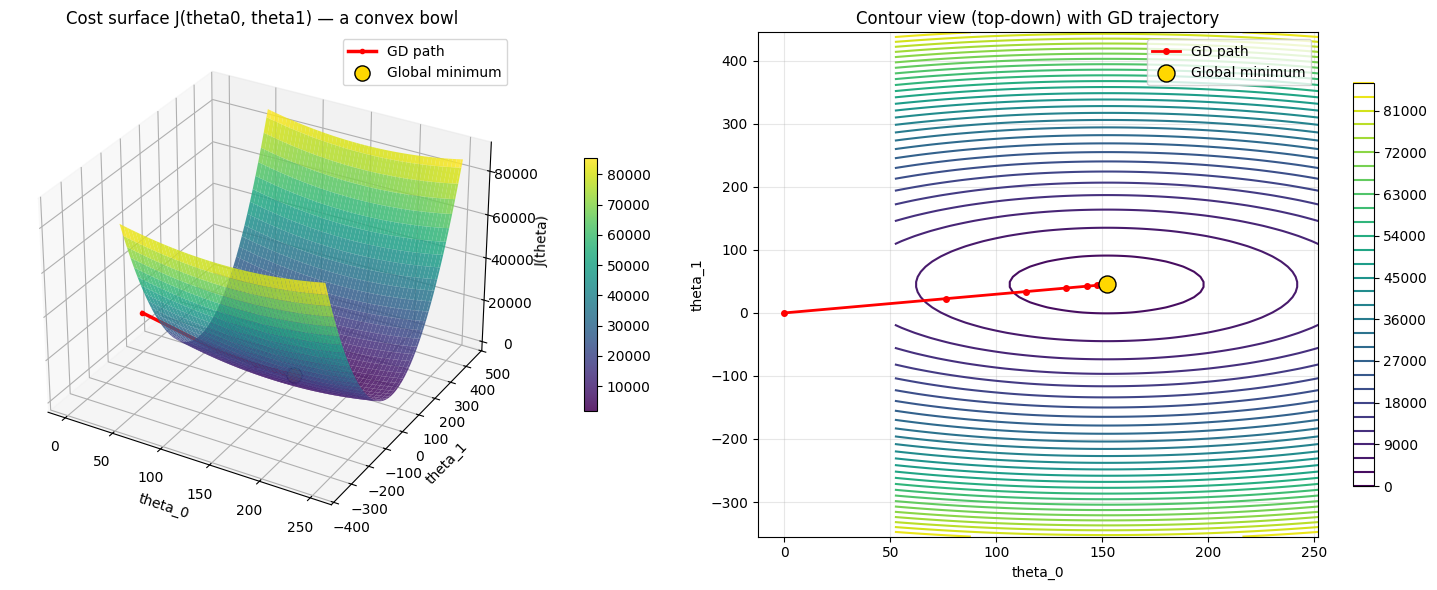

In [10]:
theta0_vals = np.linspace(theta_normal_eq[0] - 100, theta_normal_eq[0] + 100, 100)
theta1_vals = np.linspace(theta_normal_eq[1] - 400, theta_normal_eq[1] + 400, 100)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)

J_vals = np.zeros_like(T0)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        t = np.array([T0[i, j], T1[i, j]])
        J_vals[i, j] = compute_cost(X_simple, y, t)

fig = plt.figure(figsize=(15, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(T0, T1, J_vals, cmap=cm.viridis, alpha=0.85, linewidth=0, antialiased=True)
ax1.plot(theta_hist[:, 0], theta_hist[:, 1], cost_hist, color='red', linewidth=2.5,
          marker='o', markersize=3, label='GD path')
ax1.scatter([theta_normal_eq[0]], [theta_normal_eq[1]], [J_normal_eq],
            color='gold', s=120, edgecolor='black', label='Global minimum', zorder=5)
ax1.set_xlabel('theta_0')
ax1.set_ylabel('theta_1')
ax1.set_zlabel('J(theta)')
ax1.set_title('Cost surface J(theta0, theta1) — a convex bowl')
ax1.legend()
fig.colorbar(surf, ax=ax1, shrink=0.5, pad=0.1)

ax2 = fig.add_subplot(1, 2, 2)
contour = ax2.contour(T0, T1, J_vals, levels=30, cmap=cm.viridis)
ax2.plot(theta_hist[:, 0], theta_hist[:, 1], color='red', linewidth=2, marker='o', markersize=4,
         label='GD path')
ax2.scatter([theta_normal_eq[0]], [theta_normal_eq[1]], color='gold', s=150,
            edgecolor='black', zorder=5, label='Global minimum')
ax2.set_xlabel('theta_0')
ax2.set_ylabel('theta_1')
ax2.set_title('Contour view (top-down) with GD trajectory')
ax2.legend()
fig.colorbar(contour, ax=ax2, shrink=0.8)

plt.tight_layout()
plt.savefig('fig_cost_surface_static.png', dpi=140, bbox_inches='tight')
plt.show()


Two things to notice:

1. **The bowl shape (convexity)** — this is *why* gradient descent is guaranteed to find
   the global minimum for linear regression. There's only one "downhill" direction to
   follow, everywhere on the surface.
2. **The elliptical contours** — if the two parameters were on very different scales,
   these ellipses would be extremely elongated, and gradient descent would zig-zag
   slowly toward the minimum instead of taking a direct path. This is exactly the
   motivation for feature scaling (explored quantitatively in Section 9).

### 6.2 Animated version: watching the ball roll downhill

The animation below rotates the point of view slightly and reveals the gradient descent
path frame by frame, so you can watch the parameters "roll" down the bowl toward the
minimum — the large steps at the start (steep gradient, far from minimum) shrinking to
tiny steps near convergence (shallow gradient, close to minimum).

In [11]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

n_frames = 60
gd_frames = np.linspace(0, len(theta_hist) - 1, n_frames).astype(int)

def init():
    ax.plot_surface(T0, T1, J_vals, cmap=cm.viridis, alpha=0.55, linewidth=0, antialiased=True)
    ax.set_xlabel('theta_0')
    ax.set_ylabel('theta_1')
    ax.set_zlabel('J(theta)')
    ax.set_title('Gradient Descent Rolling Down the Cost Surface')
    return []

def animate(frame_idx):
    ax.clear()
    ax.plot_surface(T0, T1, J_vals, cmap=cm.viridis, alpha=0.55, linewidth=0, antialiased=True)

    i = gd_frames[frame_idx]
    ax.plot(theta_hist[:i+1, 0], theta_hist[:i+1, 1], cost_hist[:i+1],
            color='red', linewidth=2.5)
    ax.scatter([theta_hist[i, 0]], [theta_hist[i, 1]], [cost_hist[i]],
               color='red', s=80, edgecolor='black', zorder=5, label=f'Iteration {i}')
    ax.scatter([theta_normal_eq[0]], [theta_normal_eq[1]], [J_normal_eq],
               color='gold', s=120, edgecolor='black', zorder=5, label='Global minimum')

    ax.set_xlabel('theta_0')
    ax.set_ylabel('theta_1')
    ax.set_zlabel('J(theta)')
    ax.set_title(f'Gradient Descent on the Cost Surface — Iteration {i}, J={cost_hist[i]:.1f}')
    ax.view_init(elev=25, azim=30 + frame_idx * 1.5)
    ax.legend(loc='upper left')
    return []

anim = animation.FuncAnimation(fig, animate, init_func=init, frames=n_frames,
                                interval=100, blit=False)
anim.save('gradient_descent_surface.gif', writer='pillow', fps=10, dpi=100)
plt.close(fig)
print("Animation saved to gradient_descent_surface.gif")


Animation saved to gradient_descent_surface.gif


In [12]:
HTML(f'<img src="gradient_descent_surface.gif">')


## 7. Scaling Up: Gradient Descent on the Full Diabetes Feature Set

Now we extend from one feature (bmi) to all 10 features, train/test split the data, and
run batch gradient descent on the full multivariate problem. The cost surface now lives
in an 11-dimensional space ($\theta_0$ through $\theta_{10}$) that we can't plot
directly — but the same update rule, $\theta := \theta - \frac{\alpha}{m}X^T(X\theta - y)$,
applies unchanged. This is the real power of the vectorized formulation from Section 4.

In [13]:
X_full = df_scaled.drop(columns='disease_progression').values
y_full = df_scaled['disease_progression'].values

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

# Add intercept column
X_train_b = np.column_stack([np.ones(len(X_train)), X_train])
X_test_b = np.column_stack([np.ones(len(X_test)), X_test])

theta_init_full = np.zeros(X_train_b.shape[1])
alpha_full = 0.5
n_iter_full = 1000

theta_full, theta_hist_full, cost_hist_full = gradient_descent(
    X_train_b, y_train, theta_init_full, alpha_full, n_iter_full
)

print("Gradient descent coefficients (10 features + intercept):")
feature_names = ['intercept'] + list(df_scaled.drop(columns='disease_progression').columns)
for name, val in zip(feature_names, theta_full):
    print(f"  {name:10s}: {val:8.3f}")


Gradient descent coefficients (10 features + intercept):
  intercept :  151.345
  age       :    1.803
  sex       :  -11.510
  bmi       :   25.804
  bp        :   16.533
  s1        :  -43.909
  s2        :   24.321
  s3        :    7.596
  s4        :   13.034
  s5        :   34.858
  s6        :    2.313


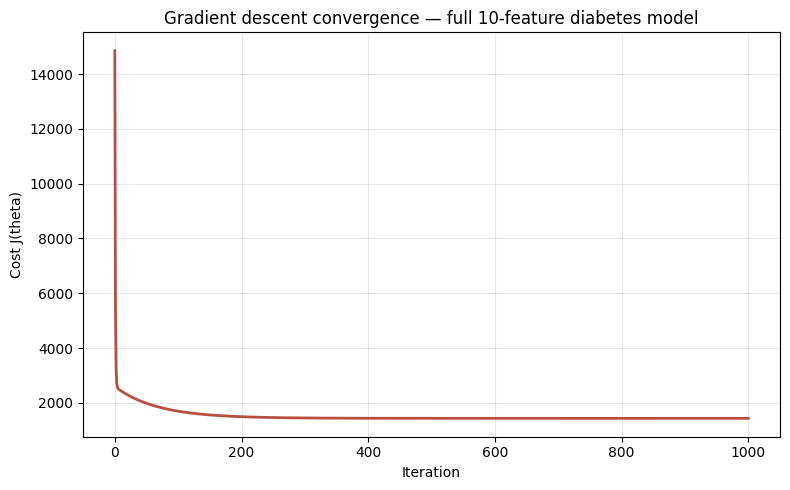

Final training cost: 1434.277


In [14]:
plt.figure(figsize=(8, 5))
plt.plot(cost_hist_full, color='#B85042', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Cost J(theta)')
plt.title('Gradient descent convergence — full 10-feature diabetes model')
plt.tight_layout()
plt.savefig('fig_convergence_full.png', dpi=140, bbox_inches='tight')
plt.show()

print(f"Final training cost: {cost_hist_full[-1]:.3f}")


## 8. Comparing Gradient Descent vs. Normal Equation vs. scikit-learn

We now check that our hand-written gradient descent, the closed-form normal equation,
and scikit-learn's production-grade implementations all agree — and compare test-set
predictive performance.

In [15]:
# 1. Our gradient descent (already computed above: theta_full)
# 2. Normal equation on the same training data
theta_normal_full = normal_equation(X_train_b, y_train)

# 3. scikit-learn's LinearRegression (uses an optimized least-squares solver internally)
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)

# 4. scikit-learn's SGDRegressor (stochastic gradient descent, for comparison of approach)
sgd_model = SGDRegressor(max_iter=2000, tol=1e-4, learning_rate='invscaling', eta0=0.01, random_state=42)
sgd_model.fit(X_train, y_train)

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': name, 'Test RMSE': rmse, 'Test R2': r2}

results = []
results.append(evaluate('Our Batch Gradient Descent', y_test, X_test_b @ theta_full))
results.append(evaluate('Normal Equation (closed-form)', y_test, X_test_b @ theta_normal_full))
results.append(evaluate('sklearn LinearRegression', y_test, sk_model.predict(X_test)))
results.append(evaluate('sklearn SGDRegressor', y_test, sgd_model.predict(X_test)))

results_df = pd.DataFrame(results)
results_df


,Model,Test RMSE,Test R2
0,Our Batch Gradient Descent,53.849909,0.452675
1,Normal Equation (closed-form),53.853446,0.452603
2,sklearn LinearRegression,53.853446,0.452603
3,sklearn SGDRegressor,53.707099,0.455574


All four approaches land on essentially the same solution and near-identical test
performance, exactly as theory predicts for a convex, well-conditioned least-squares
problem: our hand-derived batch gradient descent, the closed-form normal equation, and
scikit-learn's internal solvers are all just different roads to the same global minimum.

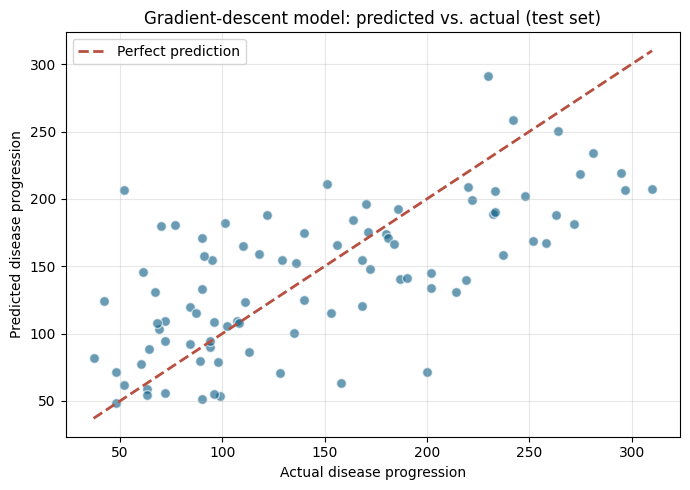

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
y_pred_gd = X_test_b @ theta_full
ax.scatter(y_test, y_pred_gd, alpha=0.6, color='#065A82', edgecolor='white', s=50)
lims = [min(y_test.min(), y_pred_gd.min()), max(y_test.max(), y_pred_gd.max())]
ax.plot(lims, lims, color='#B85042', linewidth=2, linestyle='--', label='Perfect prediction')
ax.set_xlabel('Actual disease progression')
ax.set_ylabel('Predicted disease progression')
ax.set_title('Gradient-descent model: predicted vs. actual (test set)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_predicted_vs_actual.png', dpi=140, bbox_inches='tight')
plt.show()


## 9. Diagnostics: Learning Rate and Feature Scaling

Two practical factors determine whether gradient descent converges cleanly, slowly, or
not at all: the **learning rate** $\alpha$ and **feature scaling**.

### 9.1 Effect of learning rate

- **Too small**: convergence is guaranteed but painfully slow.
- **Good**: fast, smooth convergence.
- **Too large**: the steps overshoot the minimum, and the cost can oscillate or diverge
  entirely — visible as a cost curve that increases instead of decreasing.

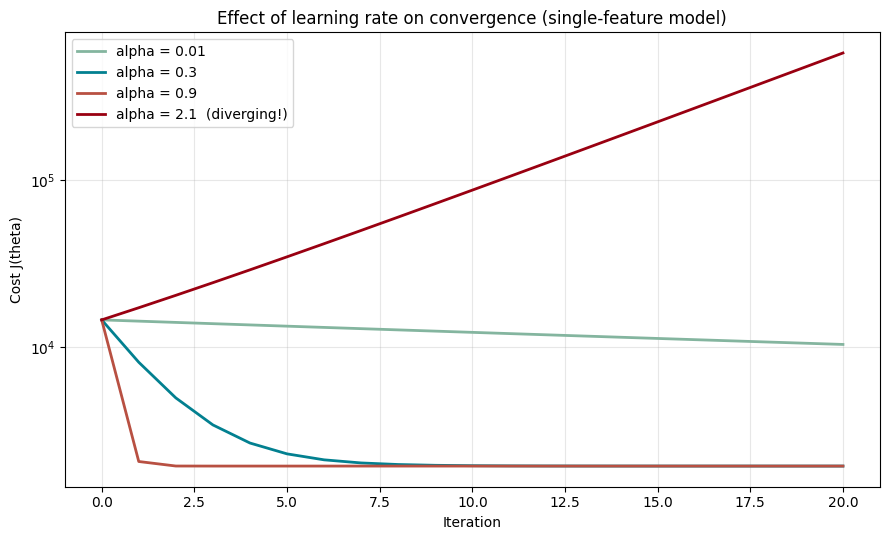

In [17]:
learning_rates = [0.01, 0.3, 0.9, 2.1]
n_iter_demo = 20

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ['#84B59F', '#028090', '#B85042', '#990011']
for alpha_test, color in zip(learning_rates, colors):
    _, _, cost_h = gradient_descent(X_simple, y, np.zeros(2), alpha_test, n_iter_demo)
    label = f'alpha = {alpha_test}'
    if cost_h[-1] > cost_h[0]:
        label += '  (diverging!)'
    ax.plot(cost_h, label=label, color=color, linewidth=2)

ax.set_xlabel('Iteration')
ax.set_ylabel('Cost J(theta)')
ax.set_yscale('symlog')
ax.set_title('Effect of learning rate on convergence (single-feature model)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_learning_rate_effect.png', dpi=140, bbox_inches='tight')
plt.show()


### 9.2 Effect of feature scaling

Standardizing every feature in Section 1 is exactly what let a single learning rate work
well across the whole model. To see why, we compare gradient descent on the bmi feature
in two forms — a realistic **raw BMI scale (roughly 18-42)** versus the **standardized**
version — using the *same* learning rate for both.

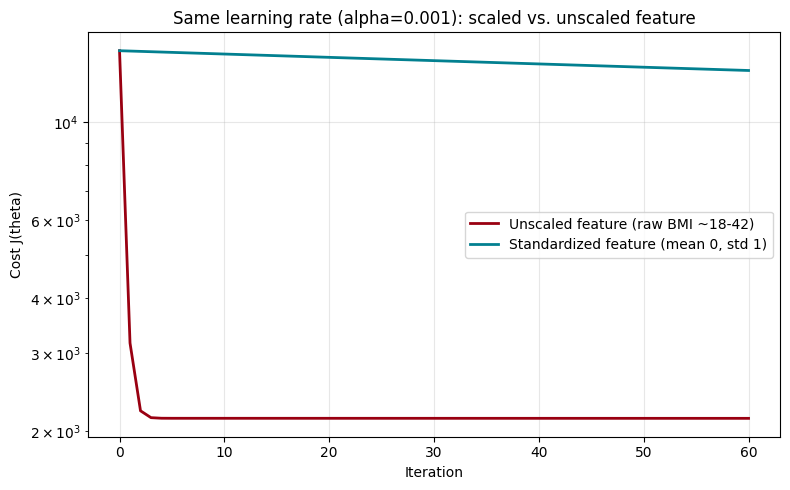

Cost after 60 iterations — unscaled:     2137.00
Cost after 60 iterations — standardized: 13112.67


In [18]:
# Simulate an unscaled feature by putting bmi on a raw-like scale (roughly 18-42, typical BMI range)
x_bmi_raw = (df['bmi'].values - df['bmi'].min()) / (df['bmi'].max() - df['bmi'].min()) * 24 + 18
X_raw = np.column_stack([np.ones(m), x_bmi_raw])

X_scaled = np.column_stack([np.ones(m), StandardScaler().fit_transform(x_bmi_raw.reshape(-1, 1)).ravel()])

alpha_compare = 0.001
n_iter_compare = 60

_, _, cost_raw = gradient_descent(X_raw, y, np.zeros(2), alpha_compare, n_iter_compare)
_, _, cost_scaled = gradient_descent(X_scaled, y, np.zeros(2), alpha_compare, n_iter_compare)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cost_raw, label='Unscaled feature (raw BMI ~18-42)', color='#990011', linewidth=2)
ax.plot(cost_scaled, label='Standardized feature (mean 0, std 1)', color='#028090', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Cost J(theta)')
ax.set_yscale('log')
ax.set_title(f'Same learning rate (alpha={alpha_compare}): scaled vs. unscaled feature')
ax.legend()
plt.tight_layout()
plt.savefig('fig_scaling_effect.png', dpi=140, bbox_inches='tight')
plt.show()

print(f"Cost after {n_iter_compare} iterations — unscaled:     {cost_raw[-1]:.2f}")
print(f"Cost after {n_iter_compare} iterations — standardized: {cost_scaled[-1]:.2f}")


Notice what happened: at $\alpha = 0.001$ — a learning rate small enough to be *safe*
for the raw BMI scale (values around 18-42) — the **standardized** feature (values
around -2 to +4) converges far more slowly, because the same step size is now tiny
relative to how far $\theta_1$ needs to move in that coordinate.

This is the real lesson: **the "right" learning rate depends on the scale of the
features it's multiplied against**, so a single global $\alpha$ cannot be optimal for
features on very different scales simultaneously. With multiple features of differing
scales (as in Section 7's 10-feature model), some coordinates would take tiny, safe
steps while others would need much larger ones — or risk diverging, as seen in Section
9.1. Standardizing every feature to the same scale first means one learning rate can
serve all of them well. That's why Section 1 standardizes the full feature set before
any gradient descent is run on it.

## 10. Conclusion

**What we covered:**

- Derived the linear regression cost function $J(\theta)$ from mean squared error, and
  showed why its convexity matters.
- Derived the **normal equation** $\theta = (X^TX)^{-1}X^Ty$ as the closed-form optimum.
- Derived the **gradient descent update rule** $\theta := \theta - \frac{\alpha}{m}X^T(X\theta-y)$
  from the calculus of the cost function.
- Implemented batch gradient descent from scratch in NumPy and validated it against the
  normal equation and scikit-learn.
- **Visualized the cost surface as a literal 3D bowl**, watched gradient descent's path
  roll downhill toward the global minimum in both a static plot and a rotating animation.
- Applied the full pipeline to real clinical data — the diabetes dataset — going from a
  single predictor (BMI) to all 10 clinical features.
- Diagnosed the two practical failure modes of gradient descent: a **learning rate**
  that's too large (divergence) or too small (crawling convergence), and **unscaled
  features** (slow, zig-zagging convergence).

**Key takeaway:** gradient descent is not a black box — it is literally rolling a ball
downhill on the cost surface, one small, calculus-derived step at a time. For linear
regression specifically, the normal equation is faster on small datasets like this one,
but the *iterative, gradient-based* approach is what scales to the deep learning models
where no closed-form solution exists at all.